# Zagadnienie 1: Szukanie miejsc zerowych. Implementacja metody Laguerre'a.
### Konrad Słotta 277442

Rozpatrzmy wielomian
$$
w(z) = a_0z^n + a_1z^{n-1} + \cdots + a_{n-1}z + a_n, \quad a_i, z \in \mathbb{C}.
$$
Zauważmy, że wielomian $w(z)$ ma dokładnie $n$ pierwiastków. Do ich znalezienia wykorzystamy metodę Laguerre'a.


### Funkcja obliczająca pochodną wielomianu
Argumenty: wsp - współczynniki wyjściowego wielomianu.

Zwraca wektor współczynników pochodnej wielomianu.

In [1]:
function pochodna(wsp::Vector)
    n = length(wsp) - 1
    
    if n < 0
        return Float64[]
    elseif n == 0
        return [0.]
    end

    wynik = similar(wsp, n)
    
    for i in 1:n
        wynik[i] = wsp[i] * (n - i + 1)
    end
    
    return wynik
end

pochodna (generic function with 1 method)

### Funkcja wyliczająca wartość wielomianu w punkcie metodą Hornera

Argumenty: wsp - współczynniki wielomianu, z - argument, dla którego obliczana jest wartość wielomianu.

Zwraca wartość wielomianu w zadanym punkcie.

In [2]:
function horner(wsp::Vector, z::Number)
    wynik = wsp[1]
    
    for i in 2:length(wsp)
        wynik = wynik * z + wsp[i]
    end
    
    return wynik
end

horner (generic function with 1 method)

### Funkcja znajdująca jeden z pierwiastków wielomianu metodą Laguerre'a
Argumenty: 
- wsp - współczynniki wielomianu,
- z0 - punkt startowy, od którego zaczynamy szukanie pierwiastków,
- eps - dokładność, z jaką szukamy miejsca zerowego,
- max_iter - maksymalna ilość iteracji funkcji.

Zwraca znaleziony pierwiastek wielomianu.

In [32]:
function laguerre_1pierwiastek(wsp::Vector{}, z0=0+0im, eps=1e-12, max_iter=100)
    n = length(wsp) - 1
    z = z0
    d1_wsp = pochodna(wsp)
    d2_wsp = pochodna(d1_wsp)
    
    for _ in 1:max_iter

        w = horner(wsp, z)
        d1 = horner(d1_wsp, z)
        d2 = horner(d2_wsp, z)

        if abs(w) < eps
            return z
        end

        H = (n - 1) * ((n - 1) * d1^2 - n * w * d2)

        denom1 = d1 +  √H
        denom2 = d1 - √H
        mianownik = abs(denom1) > abs(denom2) ? denom1 : denom2
        if abs(mianownik) < 1e-18
            z += rand() * 0.1 + rand() * 0.1im
            continue
        end
        a = (n * w) / mianownik
        z_new = z - a

        if abs(z_new - z) < eps
            return z_new
        end
        z = z_new
    end
    
    return z
end

laguerre_1pierwiastek (generic function with 4 methods)

### Funkcja usuwająca zera wiodące z listy

Argumenty: p - wektor liczb

Zwraca listę z usuniętymi zerami wiodącymi (bez zer na początku listy).

In [4]:
function trim_leading_zeros(p::Vector)
    idx = findfirst(x -> !isapprox(x, 0, atol=1e-15), p)
    return idx === nothing ? [0] : p[idx:end]
end

trim_leading_zeros (generic function with 1 method)

### Funkcja dzieląca wielomian przez dwumian schematem Hornera

Argumenty:
- p - wektor współczynników wielomianu
- root - liczba $a$ definiująca dwumian $(x - a)$, przez który wielomian zostanie podzielony

Zwraca:
- q - wektor współczynników podzielonego wielomianu,
- r - reszta wielomianu.

In [5]:
function horner_div(p::Vector, root::Number)
    n = length(p)
    q = zeros(ComplexF64, n-1)
    
    q[1] = p[1]
    for i in 2:(n-1)
        q[i] = p[i] + root*q[i-1]
    end
    r = p[end] + root*q[end]
    return q, r
end

horner_div (generic function with 1 method)

### Funkcja znajdująca wszystkie pierwiastki wielomianu wykorzystując metodę Laguerre'a
Algorytm tej funkci opiera się na znalezieniu jednego pierwiastka metodą Laguerre'a, a następnie dzieleniu wielomianu schematem Hornera. Dla podzielonego wielomianu ponownie szukamy pierwiastka metodą Laguerre'a. Dzielimy wielomian w ten sposób, dopóki nie dostaniemy dwumianu. W ten sposób zwracamy listę wszystkich pierwiastków.

Argumenty:
- wsp - współczynniki wielomianu,
- eps - dokładność, z jaką szukamy miejsc zerowych.

Zwraca wektor pierwiastków wielomianu.

In [13]:
function laguerre(wsp::Vector, z0=0.0+0.0im, eps=1e-12)
    wsp = Complex.(wsp)
    pierwiastki = Complex[]
    obecne_wsp = copy(wsp)

    while length(obecne_wsp) > 2
        pierwiastek = laguerre_1pierwiastek(obecne_wsp, z0, eps)
        push!(pierwiastki, pierwiastek)

        q, r = horner_div(obecne_wsp, pierwiastek)
        obecne_wsp = trim_leading_zeros(q)
    end

    a, b = obecne_wsp
    push!(pierwiastki, -b / a)

    return pierwiastki
end

laguerre (generic function with 3 methods)

### Przykłady działania

#### Przypadek ze współczynnikami i pierwiastkami rzeczywistymi
Rozważmy wielomian:
$$
w(x) = 6 x^5 + 7 x^4 - 58 x^3 - 79 x^2 + 64 x + 60
$$

In [34]:
wsp1 = [6, 7, -58, -79, 64, 60]
roots = laguerre(wsp1)
println(roots)

Complex[-0.6666666666666667 + 0.0im, 1.0 + 0.0im, -1.9999999999999998 + 0.0im, -2.5000000000000004 + 0.0im, 3.0 - 0.0im]


In [36]:
using Plots

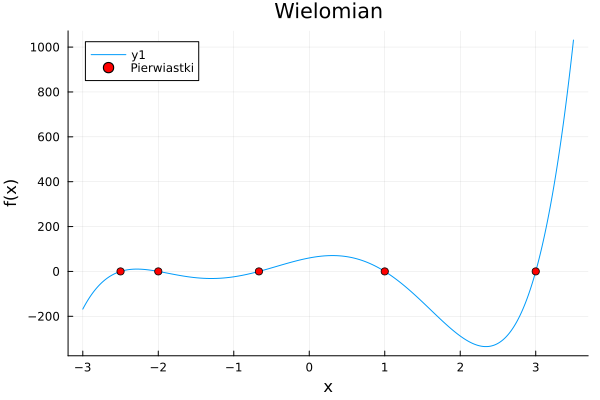

In [ ]:
f(x) = horner(wsp1, x)
x = range(-3, 3.5, length=500)
y = f.(x)

plot(x, y, xlabel="x", ylabel="f(x)", title="Wielomian")
scatter!(real.(roots), zeros(length(roots)),
         color=:red, label="Pierwiastki")

Na wykresie widzimy, że funkcja dobrze znalazła pierwiastki wielomianu w zadanej dokładności.

#### Przypadek z pierwiastkami zespolonymi
Rozważmy wielomian:
$$
W(z) = z^4 + 1, \quad z \in \mathbb{C}.
$$

In [33]:
wsp2 = [1, 0, 0, 0, 1]

roots2 = laguerre(wsp2)
println(roots2)

Complex[0.7071067811865447 + 0.7071067811865223im, 0.7071067811865223 - 0.7071067811865448im, -0.7071067811865221 + 0.7071067811865447im, -0.7071067811865448 - 0.7071067811865221im]


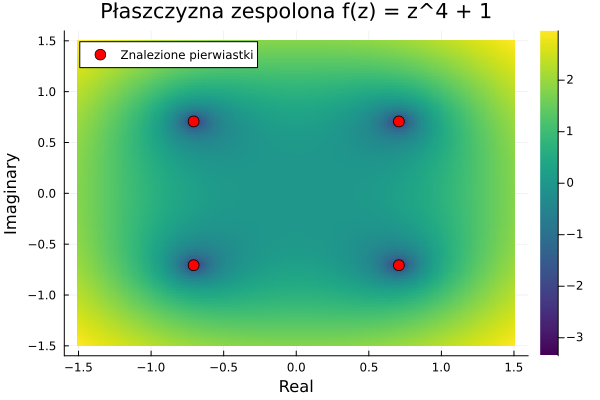

In [ ]:
f(z) = z^4 + 1

x = range(-1.5, 1.5, length=200)
y = range(-1.5, 1.5, length=200)

z_vals = [log(abs(f(re + im*im_val)) + 1e-3) for im_val in y, re in x]

heatmap(x, y, z_vals, reverse=true, c=:viridis, title="Płaszczyzna zespolona f(z) = z^4 + 1")
xlabel!("Real")
ylabel!("Imaginary")

scatter!(real.(roots2), imag.(roots2), 
         color=:red, markersize=6, label="Znalezione pierwiastki")

Na powyższym wykresie widzimy, że kropki oznaczające znalezione pierwiastki znajdują się w najbardziej ciemnoniebieskich obszarach oznaczających wartości funkcji bliskie zeru. Oznacza to, że miejsca zerowe zostały znalezione poprawnie w ramach zadanej dokładności.

#### Przypadek ze współczynnikami zespolonymi
Rozważmy wielomian:
$$
Q(z) = iz^3 + (1+i)z^2 -2z + 5i, \quad z \in \mathbb{C}.
$$

In [45]:
wsp3 = [im, 1+im, -2, 5im]
roots3 = laguerre(wsp3)
println(roots3)

Complex[0.13560705476461443 + 1.372145115699254im, 0.8643929452353856 - 1.372145115699254im, -2.0 + 1.0im]


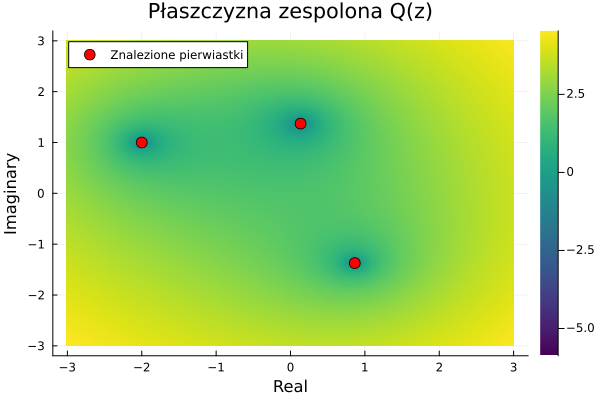

In [46]:
Q(z) = im*z^3 + (1+im)z^2 - 2z + 5im
x = range(-3, 3, length=200)
y = range(-3, 3, length=200)

z_vals = [log(abs(Q(re + im*im_val)) + 1e-3) for im_val in y, re in x]

heatmap(x, y, z_vals, reverse=true, c=:viridis, title="Płaszczyzna zespolona Q(z)")
xlabel!("Real")
ylabel!("Imaginary")

scatter!(real.(roots3), imag.(roots3), 
         color=:red, markersize=6, label="Znalezione pierwiastki")

Na powyższym wykresie widzimy, że kropki oznaczające znalezione pierwiastki znajdują się w najbardziej ciemnoniebieskich obszarach oznaczających wartości funkcji bliskie zeru. Oznacza to, że miejsca zerowe zostały znalezione poprawnie w ramach zadanej dokładności.

In [48]:
import Pkg
Pkg.add("BenchmarkTools")

   Resolving package versions...
   Installed Compat ───────── v4.18.1
   Installed BenchmarkTools ─ v1.7.0
    Updating `C:\Users\konra\.julia\environments\v1.12\Project.toml`
  [6e4b80f9] + BenchmarkTools v1.7.0
    Updating `C:\Users\konra\.julia\environments\v1.12\Manifest.toml`
  [6e4b80f9] + BenchmarkTools v1.7.0
  [34da2185] + Compat v4.18.1
  [9abbd945] + Profile v1.11.0
Precompiling packages...
   2389.6 ms  ✓ Compat
    782.8 ms  ✓ Compat → CompatLinearAlgebraExt
   2002.7 ms  ✓ BenchmarkTools
  3 dependencies successfully precompiled in 7 seconds. 211 already precompiled.


### Porównanie funkcji laguerre_1pierwiastek i Roots.find_zero
Rozważmy ponownie wielomian:
$$
W(z) = z^4 +1 \quad z \in \mathbb{C}.
$$

In [81]:
using Roots
wsp = [1, 0, 0, 0, 1]
z0 = 0.5 + 0.5im
f(z) = z^4 + 1
f_prime(z) = 4z^3

r_laguerre = laguerre_1pierwiastek(wsp, z0)
r_roots = find_zero((f, f_prime), z0, Roots.Newton())

println(r_laguerre)
println(r_roots)

0.7071067811865475 + 0.7071067811865475im
0.7071067811865476 + 0.7071067811865476im


Obydwie funkcje znalazły ten sam pierwiastek.

#### Analiza dokładności

In [83]:
err_laguerre = abs(f(r_laguerre))
err_roots = abs(f(r_roots))

println("Błąd Laguerre: $err_laguerre")
println("Błąd Roots:    $err_roots")

Błąd Laguerre: 4.440892098500626e-16
Błąd Roots:    4.440892098500626e-16


W obu funkcjach błąd wyszedł taki sam - bardzo bliski zeru.

#### Analiza szybkości

In [79]:
using BenchmarkTools

t_laguerre = @benchmark laguerre_1pierwiastek($wsp, $z0)

BenchmarkTools.Trial: 10000 samples with 10 evaluations per sample.
 Range (min … max):  1.380 μs …  2.441 ms  ┊ GC (min … max): 0.00% … 99.69%
 Time  (median):     2.380 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   2.730 μs ± 24.845 μs  ┊ GC (mean ± σ):  8.91% ±  1.00%

  █               ▁                                           
  ██▆▂▄▃▂▂▂▃▅▆▄▅▆▇█▇▆▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▂
  1.38 μs        Histogram: frequency by time        5.25 μs <

 Memory estimate: 2.16 KiB, allocs estimate: 79.

In [80]:
t_roots = @benchmark find_zero(($f, $f_prime), $z0, Roots.Newton())

BenchmarkTools.Trial: 10000 samples with 199 evaluations per sample.
 Range (min … max):  417.085 ns …  20.156 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     482.915 ns               ┊ GC (median):    0.00%
 Time  (mean ± σ):   541.545 ns ± 460.805 ns  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▇▄▄▄▇█▃▂▁▂▂▁▂▂▂▁             ▂  ▂  ▂                          ▂
  ████████████████▇████▆█▆█▇▇█▇█▆▆█▇▇█▆▇█▅▅▇▆▆▅▅▄▄▅▆▆▄▄▄▆▆▄▄▄▄▅ █
  417 ns        Histogram: log(frequency) by time       1.22 μs <

 Memory estimate: 0 bytes, allocs estimate: 0.

Funkcja z biblioteki Roots okazała się szybsza oraz bardziej wydajna pod względem wykorzystywania pamięci.